In [8]:
import copy
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from torchvision import models, transforms
from torchvision.datasets import ImageFolder

from torch.utils.data import (
    DataLoader,
    random_split,
    Dataset
)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [10]:
UCMERCED_PATH = "../dataset/UCMerced"

In [11]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [12]:
dataset = ImageFolder(UCMERCED_PATH)

print("Classes :", len(dataset.classes))

print(dataset.classes)

Classes : 21
['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [13]:
train_size = int(0.8 * len(dataset))

val_size = len(dataset) - train_size

train_subset, val_subset = random_split(

    dataset,

    [train_size, val_size],

    generator=torch.Generator().manual_seed(42)

)

In [14]:
class TransformDataset(Dataset):

    def __init__(self, subset, transform):

        self.subset = subset

        self.transform = transform

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        image = self.transform(image)

        return image, label

In [15]:
train_dataset = TransformDataset(
    train_subset,
    train_transform
)

val_dataset = TransformDataset(
    val_subset,
    val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [16]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    10
)

model.load_state_dict(
    torch.load("../models/resnet18_best.pth")
)

<All keys matched successfully>

In [17]:
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    21
)

model = model.to(device)

In [18]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the classifier
for param in model.fc.parameters():
    param.requires_grad = True

In [19]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [21]:
def train_model(model, train_loader, val_loader,
                criterion, optimizer, epochs):

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_acc = 0

    for epoch in range(epochs):

        # ---------- Training ----------
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ---------- Validation ----------
        model.eval()

        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.2f}%")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.2f}%")
        print("-"*50)

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "../models/ucmerced_best.pth"
            )

    return train_losses, val_losses, train_accs, val_accs

In [22]:
train_losses1, val_losses1, train_accs1, val_accs1 = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=3
)

Epoch 1/3
Train Loss : 2.3443
Train Acc  : 36.79%
Val Loss   : 1.5611
Val Acc    : 66.19%
--------------------------------------------------
Epoch 2/3
Train Loss : 1.2627
Train Acc  : 75.77%
Val Loss   : 0.9789
Val Acc    : 83.81%
--------------------------------------------------
Epoch 3/3
Train Loss : 0.8788
Train Acc  : 83.93%
Val Loss   : 0.7504
Val Acc    : 85.48%
--------------------------------------------------


In [23]:
# Keep all layers frozen first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Layer 3
for param in model.layer3.parameters():
    param.requires_grad = True

# Unfreeze Layer 4
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

In [24]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [25]:
train_losses2, val_losses2, train_accs2, val_accs2 = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch 1/5
Train Loss : 0.3523
Train Acc  : 91.90%
Val Loss   : 0.1980
Val Acc    : 93.57%
--------------------------------------------------
Epoch 2/5
Train Loss : 0.1141
Train Acc  : 97.74%
Val Loss   : 0.1649
Val Acc    : 94.05%
--------------------------------------------------
Epoch 3/5
Train Loss : 0.0611
Train Acc  : 98.99%
Val Loss   : 0.0977
Val Acc    : 95.48%
--------------------------------------------------
Epoch 4/5
Train Loss : 0.0372
Train Acc  : 99.29%
Val Loss   : 0.0811
Val Acc    : 95.95%
--------------------------------------------------
Epoch 5/5
Train Loss : 0.0330
Train Acc  : 99.52%
Val Loss   : 0.1020
Val Acc    : 96.19%
--------------------------------------------------


In [26]:
torch.save(
    model.state_dict(),
    "../models/resnet18_ucmerced_final.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!


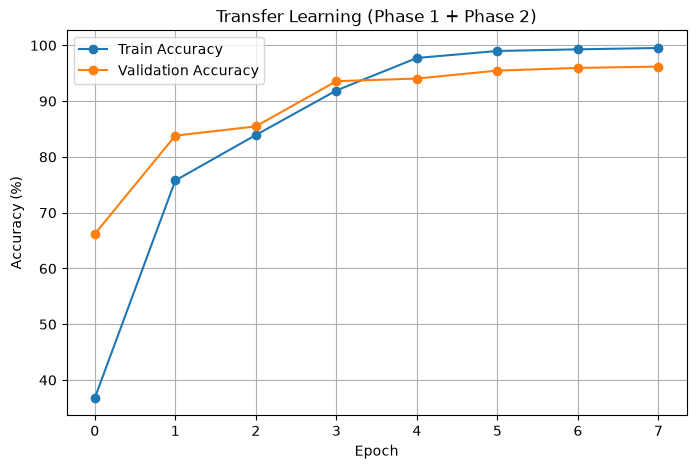

In [27]:
all_train_acc = train_accs1 + train_accs2
all_val_acc = val_accs1 + val_accs2

plt.figure(figsize=(8,5))

plt.plot(all_train_acc, marker='o', label="Train Accuracy")
plt.plot(all_val_acc, marker='o', label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Transfer Learning (Phase 1 + Phase 2)")
plt.legend()
plt.grid(True)

plt.show()

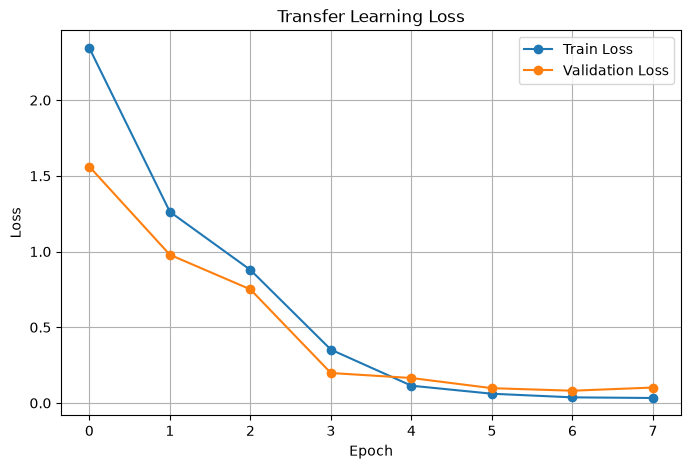

In [28]:
all_train_loss = train_losses1 + train_losses2
all_val_loss = val_losses1 + val_losses2

plt.figure(figsize=(8,5))

plt.plot(all_train_loss, marker='o', label="Train Loss")
plt.plot(all_val_loss, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning Loss")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
print("Best Validation Accuracy (Phase 1):", max(val_accs1))
print("Best Validation Accuracy (Phase 2):", max(val_accs2))



Best Validation Accuracy (Phase 1): 85.47619047619048
Best Validation Accuracy (Phase 2): 96.19047619047619


In [30]:
print(model.fc)

Linear(in_features=512, out_features=21, bias=True)


In [31]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Phase": [
        "Phase 1 (Frozen Backbone)",
        "Phase 2 (Fine-Tuning)"
    ],
    "Trainable Layers": [
        "Classifier (fc) only",
        "Layer3 + Layer4 + Classifier"
    ],
    "Epochs": [
        3,
        5
    ],
    "Learning Rate": [
        0.001,
        0.0001
    ],
    "Best Validation Accuracy (%)": [
        round(max(val_accs1), 2),
        round(max(val_accs2), 2)
    ]
})

comparison_df

,Phase,Trainable Layers,Epochs,Learning Rate,Best Validation Accuracy (%)
0,Phase 1 (Frozen Backbone),Classifier (fc) only,3,0.0010,85.48
1,Phase 2 (Fine-Tuning),Layer3 + Layer4 + Classifier,5,0.0001,96.19
